##### 복습

In [1]:
# Data 가져오기와 데이터 분류
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 정규화
train_scaled = train_input / 255.0

# train 과 valid data 생성
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [7]:
# Model 함수
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape = (28,28)))
    model.add(keras.layers.Dense(100, activation='relu'))   # 이미지는 relu 가 잘 함
    if a_layer:
        model.add(a_layer)      # a_layer 에 값이 들어오면 추가.
    model.add(keras.layers.Dense(10, activation='softmax')) # 출력층에는 10개, 그리고 softmax
    return model

In [8]:
# 모델 구성 및 Summary
model = model_fn()
model.summary()

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 훈련 및 과정에 대한 history 보기  # history : 
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_scaled, train_target, epochs=5)       # loss : 손실함수

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8129 - loss: 0.5357
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8594 - loss: 0.3915
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8723 - loss: 0.3539
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8806 - loss: 0.3315
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8859 - loss: 0.3157


----
#### 여기부턴 새로운 내용

In [10]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

### 손실곡선

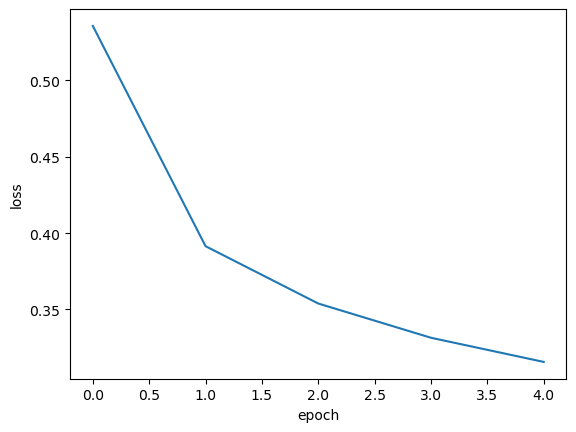

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

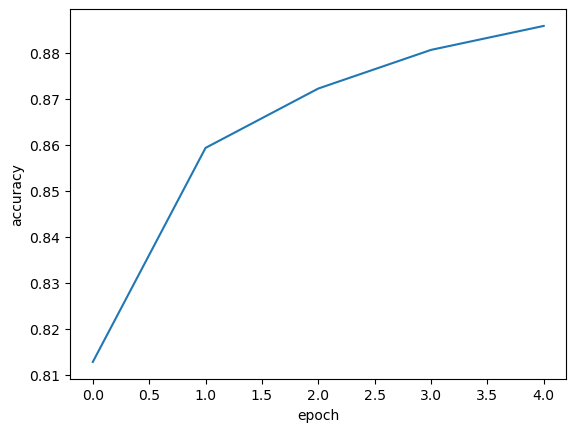

In [12]:
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

> Epochs 를 늘리면 정확도가 더 올라가고 손실이 더 떨어질 거 같음

----
#### 반복 훈련의 증가(epochs의 증가)

In [13]:
model = model_fn()
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(train_scaled, train_target, epochs=20)

Epoch 1/20


c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8134 - loss: 0.5355
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8605 - loss: 0.3922
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8732 - loss: 0.3567
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8809 - loss: 0.3329
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8860 - loss: 0.3176
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8912 - loss: 0.3067
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8940 - loss: 0.2959
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8976 - loss: 0.2875
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8997 - loss: 0.2794
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9046 - loss: 0.2713
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9062 - loss: 0.2672
Epoch 12/20
1500/1500 ━━━━━━━━━━━━━━━━━━━

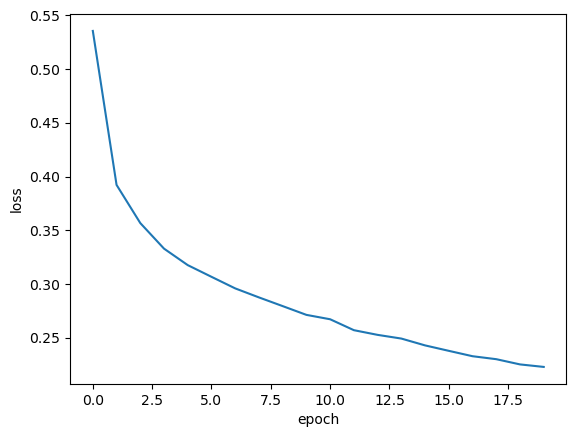

In [14]:
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

----
#### 검증 손실도 같이 봄
 : 검증세트에 대한 정확도를 파악

In [17]:
model = model_fn()
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target))        # validation_data 를 적으면 학습 후 train과 val 같이 구함

Epoch 1/20


c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8128 - loss: 0.5307 - val_accuracy: 0.8482 - val_loss: 0.4324
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8593 - loss: 0.3919 - val_accuracy: 0.8708 - val_loss: 0.3665
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8725 - loss: 0.3526 - val_accuracy: 0.8512 - val_loss: 0.4112
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8808 - loss: 0.3311 - val_accuracy: 0.8655 - val_loss: 0.3776
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8866 - loss: 0.3158 - val_accuracy: 0.8395 - val_loss: 0.4857
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8908 - loss: 0.3034 - val_accuracy: 0.8716 - val_loss: 0.3676
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8959 - loss: 0.2917 - val_accuracy: 0.8816 - val_loss: 0.3480
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8972 - loss: 0.2845 - val_accurac

In [19]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

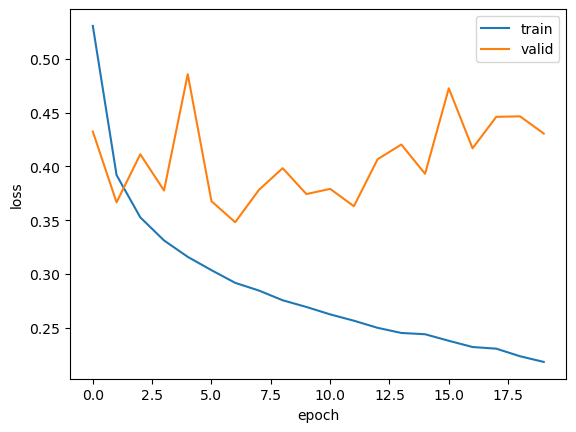

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

: val 과 train 의 loss 가 같이 내려가는 순간이 좋은 곳

> 훈련세트는 epochs 가 증가됨에 따라 손실이 떨어지고 있으나, 검증세트는 epochs 가 증가됨에 따라 초반에는 손실이 떨어졌으나, 진행할수록 손실이 증가한다.
이 모델은 훈련세트의 정확도가 높아 좋지만 검증세트에는 적합하지 않은 과대적합 모델이다.

----
#### Optimizer 사용해보자. 
##### (optimizer : 손실(loss)을 줄이기 위해 신경망의 가중치와 편향을 어떻게 업데이트할지 결정하는 알고리즘)

In [25]:
model = model_fn()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8173 - loss: 0.5226 - val_accuracy: 0.8523 - val_loss: 0.4171
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8581 - loss: 0.3938 - val_accuracy: 0.8573 - val_loss: 0.3940
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8739 - loss: 0.3528 - val_accuracy: 0.8670 - val_loss: 0.3750
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8795 - loss: 0.3268 - val_accuracy: 0.8744 - val_loss: 0.3542
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8894 - loss: 0.3048 - val_accuracy: 0.8726 - val_loss: 0.3490
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8931 - loss: 0.2912 - val_accuracy: 0.8770 - val_loss: 0.3335
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8978 - loss: 0.2776 - val_accuracy: 0.8848 - val_loss: 0.3184
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9026 - loss: 0.2650 - 

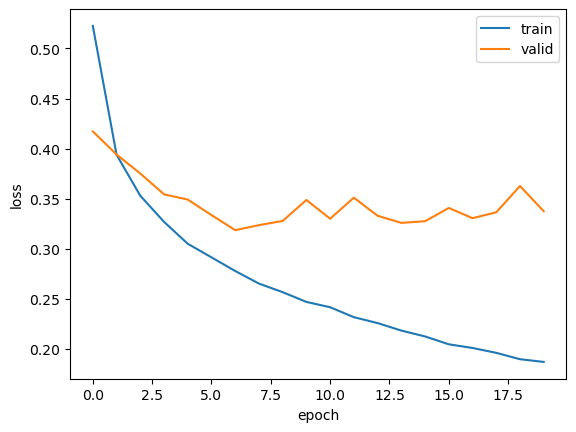

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

> optimizer (최적화 알고리즘)을 사용해서 train 과 valid 의 손실율이 조금 더 비슷해지고 valid 의 손실율이 안정화되었으나, 아직 과대적합이다.

----
#### Dropout
: 훈련 시 각 데이터를 처리할 때 데이터의 갯수를 랜덤으로 줄인다.

In [29]:
# model 에 dropout 을 추가
model = model_fn(keras.layers.Dropout(0.3))     # 0.3 은 % 임
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7921 - loss: 0.5912 - val_accuracy: 0.8462 - val_loss: 0.4228
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8411 - loss: 0.4417 - val_accuracy: 0.8605 - val_loss: 0.3859
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8534 - loss: 0.4039 - val_accuracy: 0.8646 - val_loss: 0.3629
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8609 - loss: 0.3829 - val_accuracy: 0.8684 - val_loss: 0.3572
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8657 - loss: 0.3660 - val_accuracy: 0.8740 - val_loss: 0.3481
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8703 - loss: 0.3524 - val_accuracy: 0.8739 - val_loss: 0.3474
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8729 - loss: 0.3455 - val_accuracy: 0.8791 - val_loss: 0.3310
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8768 - loss: 0.3347 - 

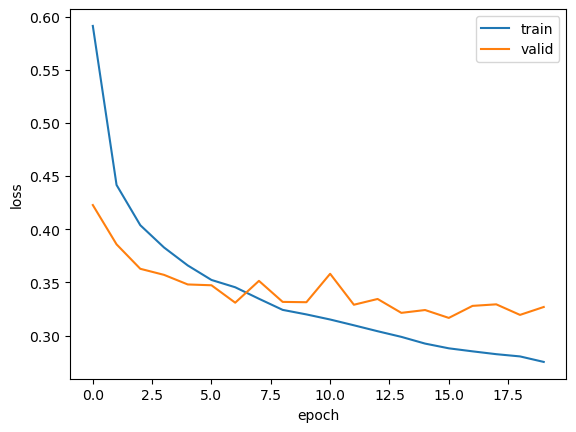

In [31]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

> epochs 가 9일 경우 train 과 valid 의 차이가 적은 것 같다. (현재 내 그래프는 8인듯)
기본적으로 훈련세트의 손실이 검증세트보다 적게 나오는 epochs 를 선택

In [32]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(train_scaled, train_target, epochs=9, validation_data=(val_scaled, val_target))

Epoch 1/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7938 - loss: 0.5867 - val_accuracy: 0.8468 - val_loss: 0.4294
Epoch 2/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8419 - loss: 0.4361 - val_accuracy: 0.8602 - val_loss: 0.3808
Epoch 3/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8545 - loss: 0.4014 - val_accuracy: 0.8625 - val_loss: 0.3774
Epoch 4/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8610 - loss: 0.3812 - val_accuracy: 0.8688 - val_loss: 0.3543
Epoch 5/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8649 - loss: 0.3659 - val_accuracy: 0.8728 - val_loss: 0.3474
Epoch 6/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8706 - loss: 0.3529 - val_accuracy: 0.8760 - val_loss: 0.3434
Epoch 7/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8738 - loss: 0.3442 - val_accuracy: 0.8749 - val_loss: 0.3476
Epoch 8/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8767 - loss: 0.3358 - val_accu

----
#### 모델의 저장과 복원

In [33]:
# 모델의 저장
model.save('../Data/model_fashion.keras')

In [34]:
# 복원
model1 = keras.models.load_model('../Data/model_fashion.keras')

In [35]:
# 사용
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step - accuracy: 0.8806 - loss: 0.3362


[0.33623164892196655, 0.8805833458900452]

----
#### Callbacks
 : 훈련 수행 시 손실 값이 제일 작은 모델을 자동으로 저장해준다  <- 편함     
  방식 : epoch 횟수가 올라갈 때마다 저장 후, 만약 accuracy 가 증가했다면 이전 파일 삭제 후 저장, 아니면 패스

In [37]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_model.keras")

history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target),
                    callbacks = [checkpoint_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7934 - loss: 0.5909 - val_accuracy: 0.8432 - val_loss: 0.4368
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8425 - loss: 0.4408 - val_accuracy: 0.8573 - val_loss: 0.3879
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8532 - loss: 0.4029 - val_accuracy: 0.8619 - val_loss: 0.3780
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8613 - loss: 0.3811 - val_accuracy: 0.8690 - val_loss: 0.3620
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8652 - loss: 0.3657 - val_accuracy: 0.8776 - val_loss: 0.3365
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8709 - loss: 0.3528 - val_accuracy: 0.8773 - val_loss: 0.3388
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8748 - loss: 0.3408 - val_accuracy: 0.8800 - val_loss: 0.3325
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8785 - loss: 0.3346 - 

In [38]:
# 복원
model1 = keras.models.load_model('../Data/best_model.keras')
# 사용
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - accuracy: 0.8903 - loss: 0.3198


[0.31982582807540894, 0.890333354473114]

----
#### Early-Stopping (조기종료)
 : Callbacks 를 끝까지 기다리는 것이 아니고 patience(Hyper parameter) 를 선정하여 한계값을 정해 실행한다.
    patience : 지정한 횟수만큼 정확도가 떨어져도 일단 참고 넘어감. (잠시 떨어졌다가 오를 것 대비)

In [43]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_model.keras",  save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,       # 이 횟수는 직접 지정하면 됨
    restore_best_weights=True   # 만약 위에 지정한 횟수 이상으로 감소했을 경우 종료하고 가장 loss 가 적은 걸 가져옴.
)

history = model.fit(train_scaled, train_target, epochs=20, validation_data=(val_scaled, val_target),
                    callbacks = [checkpoint_cb, early_stopping_cb])

Epoch 1/20


c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7886 - loss: 0.5991 - val_accuracy: 0.8480 - val_loss: 0.4150
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8400 - loss: 0.4435 - val_accuracy: 0.8547 - val_loss: 0.3926
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8535 - loss: 0.4038 - val_accuracy: 0.8647 - val_loss: 0.3788
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8606 - loss: 0.3833 - val_accuracy: 0.8624 - val_loss: 0.3632
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8649 - loss: 0.3672 - val_accuracy: 0.8688 - val_loss: 0.3685
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8705 - loss: 0.3536 - val_accuracy: 0.8746 - val_loss: 0.3437
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8752 - loss: 0.3418 - val_accuracy: 0.8770 - val_loss: 0.3327
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8767 - loss: 0.3355 - val_accurac

In [44]:
# 몇 번째 epoch 에서 stop 되었는가?
early_stopping_cb.stopped_epoch     # 위에서 12번 했음. 0 ~ 11 까지 12번 이라 11로 나오는 거임.

11

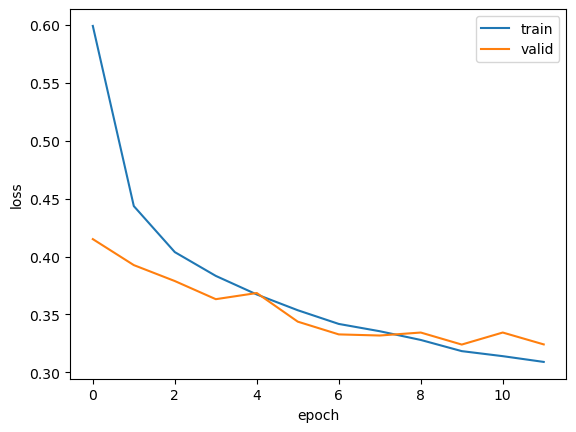

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [46]:
# 복원
model1 = keras.models.load_model('../Data/best_model.keras')
# 사용
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.8813 - loss: 0.3240


[0.3239697813987732, 0.8813333511352539]